In [2]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
data_path = Path("../exploration/data/coffee_sales_model.parquet")

daily_sales = pd.read_parquet(data_path)
daily_sales.head()

,sales_quantity,was_missing,day_of_week_num,month,year,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14
date,,,,,,,,,,,,
2024-03-01,11,False,4,3,2024,0,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-02,7,False,5,3,2024,1,11.0,NaN,NaN,NaN,NaN,NaN
2024-03-03,10,False,6,3,2024,1,7.0,NaN,NaN,NaN,NaN,NaN
2024-03-04,4,False,0,3,2024,0,10.0,NaN,NaN,NaN,NaN,NaN
2024-03-05,9,False,1,3,2024,0,4.0,NaN,NaN,NaN,NaN,NaN


In [7]:
def calculate_forecast_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    wape = (
        np.sum(np.abs(y_true - y_pred)) /
        np.sum(np.abs(y_true))
    ) * 100

    return {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "WAPE (%)": round(wape, 2)
    }

In [8]:
validation_horizon = 30
test_horizon = 30

train = daily_sales.iloc[:-(validation_horizon + test_horizon)].copy()
validation = daily_sales.iloc[-(validation_horizon + test_horizon):-test_horizon].copy()
test = daily_sales.iloc[-test_horizon:].copy()

train_validation = pd.concat([train, validation], axis=0)

y_train = train["sales_quantity"]
y_validation = validation["sales_quantity"]
y_test = test["sales_quantity"]

y_train_validation = train_validation["sales_quantity"]

print("Train:", train.index.min(), "to", train.index.max(), "|", len(train))
print("Validation:", validation.index.min(), "to", validation.index.max(), "|", len(validation))
print("Test:", test.index.min(), "to", test.index.max(), "|", len(test))

Train: 2024-03-01 00:00:00 to 2025-01-22 00:00:00 | 328
Validation: 2025-01-23 00:00:00 to 2025-02-21 00:00:00 | 30
Test: 2025-02-22 00:00:00 to 2025-03-23 00:00:00 | 30


## baseline

In [9]:
from modules.modeling.prediction import ForecastPredictor

In [10]:
def moving_average_forecast(history, target_index, window=7):
    extended_series = history["sales_quantity"].copy()
    forecast = pd.Series(index=target_index, dtype=float)

    for date in target_index:
        forecast.loc[date] = extended_series.iloc[-window:].mean()
        extended_series.loc[date] = forecast.loc[date]

    forecast.name = f"moving_average_{window}d_forecast"

    return forecast

In [13]:
forecast_predictor = ForecastPredictor()

ma7_validation_forecast = forecast_predictor.moving_average_forecast(
    history=train,
    target_index=y_validation.index,
    window=7
)

ma7_test_forecast = forecast_predictor.moving_average_forecast(
    history=train_validation,
    target_index=y_test.index,
    window=7
)

## holt-winters

In [14]:
best_hw_params, hw_tuning_results = forecast_predictor.tune_exponential_smoothing(
    y_train=y_train,
    y_validation=y_validation
)

hw_forecast = forecast_predictor.fit_predict_exponential_smoothing(
    y_train=y_train_validation,
    y_test=y_test,
    best_params=best_hw_params
)

c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\.venv_nestle\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\.venv_nestle\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\.venv_nestle\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\.venv_nestle\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D wi

## SARIMA

In [15]:
best_sarima_params, sarima_tuning_results = forecast_predictor.tune_sarima(
    y_train=y_train,
    y_validation=y_validation
)

sarima_forecast = forecast_predictor.fit_predict_sarima(
    y_train=y_train_validation,
    y_test=y_test,
    best_params=best_sarima_params
)

c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\.venv_nestle\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\.venv_nestle\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\.venv_nestle\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\.venv_nestle\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D wi

## RF

In [16]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    # "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
]

ml_train = train.copy()
ml_validation = validation.copy()
ml_test = test.copy()
ml_train_validation = train_validation.copy()

X_train = ml_train[features]
y_train_ml = ml_train["sales_quantity"]

X_validation = ml_validation[features]
y_validation_ml = ml_validation["sales_quantity"]

X_test = ml_test[features]
y_test_ml = ml_test["sales_quantity"]

X_train_validation = ml_train_validation[features]
y_train_validation_ml = ml_train_validation["sales_quantity"]

In [17]:
best_rf_params, rf_tuning_results = forecast_predictor.tune_random_forest(
    X_train=X_train,
    y_train=y_train_ml,
    X_validation=X_validation,
    y_validation=y_validation_ml
)

rf_forecast = forecast_predictor.fit_predict_random_forest(
    X_train=X_train_validation,
    y_train=y_train_validation_ml,
    X_test=X_test,
    best_params=best_rf_params
)

## Comparação teste

In [21]:
forecasts = {
    "Baseline": ma7_test_forecast,
    "Exponential Smoothing Tuned": hw_forecast[1],
    "SARIMA Tuned": sarima_forecast[1],
    "RF with Lags": rf_forecast[1]
}

In [23]:
from modules.modeling.metrics import ForecastMetrics

horizons = {
    "next_day": 1,
    "next_week": 7,
    "next_month": 30
}

results_by_horizon = ForecastMetrics.evaluate_by_horizon(
    y_test=y_test,
    forecasts=forecasts,
    horizons=horizons
)

results_by_horizon

,horizon,n_days,model,MAE,RMSE,WAPE (%)
3,next_day,1,RF with Lags,8.80,8.80,176.09
2,next_day,1,SARIMA Tuned,11.41,11.41,228.24
0,next_day,1,Baseline,12.00,12.00,240.00
1,next_day,1,Exponential Smoothing Tuned,13.16,13.16,263.14
11,next_month,30,RF with Lags,4.09,4.72,29.35
10,next_month,30,SARIMA Tuned,4.73,5.56,33.95
8,next_month,30,Baseline,5.13,6.47,36.84
9,next_month,30,Exponential Smoothing Tuned,5.47,6.68,39.23
7,next_week,7,RF with Lags,4.74,5.48,33.51
4,next_week,7,Baseline,5.14,6.76,36.36


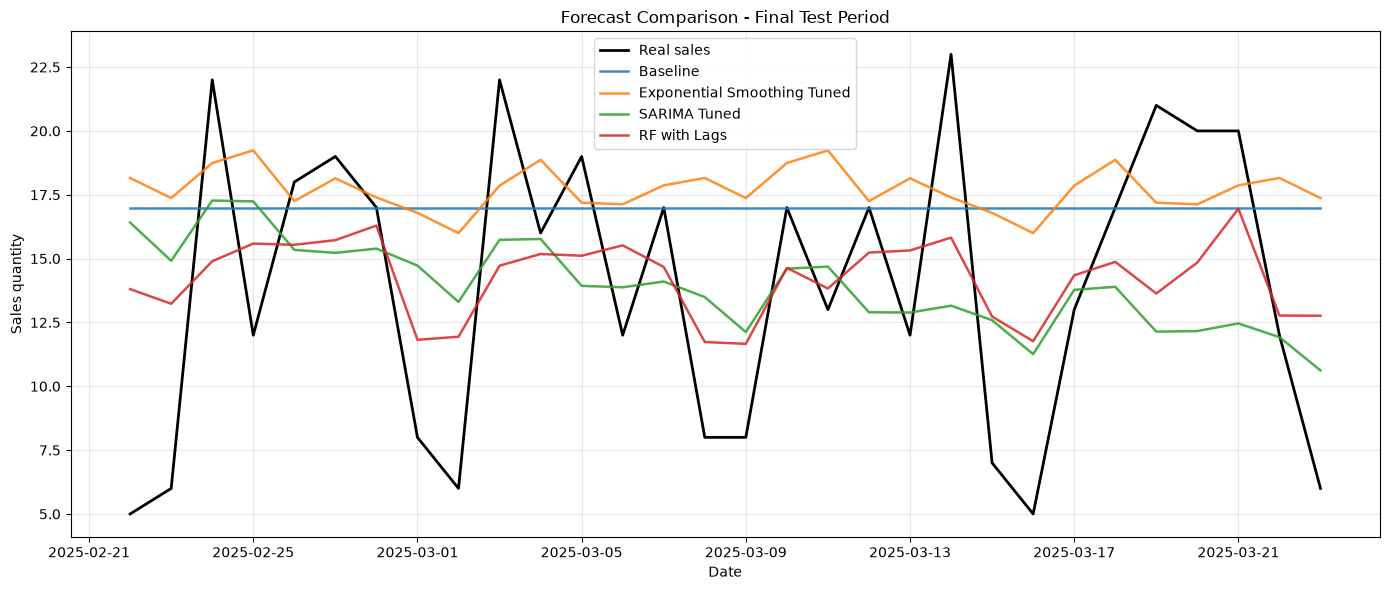

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test,
    label="Real sales",
    color="black",
    linewidth=2
)

for model_name, forecast in forecasts.items():
    common_index = y_test.index.intersection(forecast.index)

    plt.plot(
        common_index,
        forecast.loc[common_index],
        label=model_name,
        linewidth=1.8,
        alpha=0.85
    )

plt.title("Forecast Comparison - Final Test Period")
plt.xlabel("Date")
plt.ylabel("Sales quantity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
def fit_predict_random_forest(X_train, y_train, X_test, best_params):
    max_depth = best_params["max_depth"]

    if pd.isna(max_depth):
        max_depth = None
    else:
        max_depth = int(max_depth)

    params = {
        "n_estimators": int(best_params["n_estimators"]),
        "max_depth": max_depth,
        "min_samples_leaf": int(best_params["min_samples_leaf"]),
        "max_features": best_params["max_features"],
    }

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    forecast = pd.Series(
        model.predict(X_test),
        index=X_test.index,
        name="random_forest_lags_forecast"
    )

    return model, forecast

In [65]:
rf_model, rf_forecast = fit_predict_random_forest(
    X_train=X_train_validation,
    y_train=y_train_validation_ml,
    X_test=X_test,
    best_params=best_rf_params
)

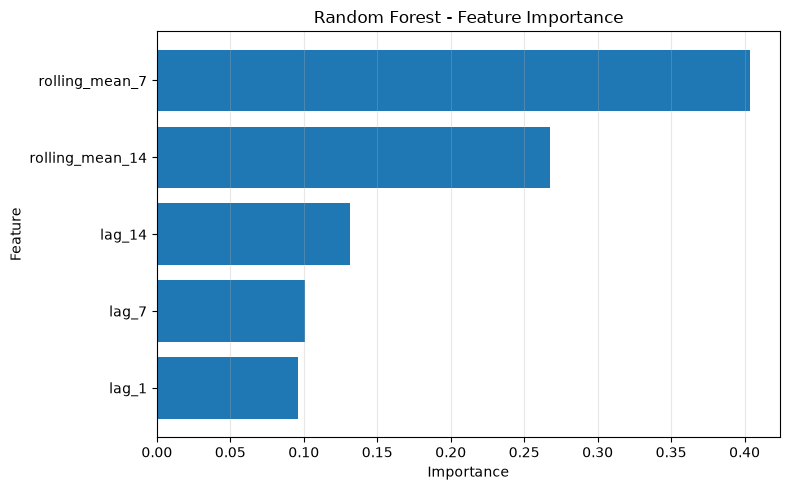

In [66]:
feature_importance = pd.DataFrame({
    "feature": X_train_validation.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()